## Étape 1 : Installation et Configuration

In [1]:
# Installation des dépendances
!pip install -q pyspark==3.5.0 torch torchvision pillow kagglehub
!apt-get install -qq openjdk-11-jdk-headless > /dev/null

import os
import sys

# Configuration Java pour Spark
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PATH'] = os.environ['JAVA_HOME'] + '/bin:' + os.environ['PATH']

# Initialisation Spark avec configuration optimisée
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PneumoniaDistributed") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "8") \
    .getOrCreate()

print("=" * 60)
print("✅ Spark initialisé - Version:", spark.version)
print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.1 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
✅ Spark initialisé - Version: 3.5.0


## Étape 2 : Chargement distribué des images

In [2]:
import kagglehub
from pyspark.sql.functions import udf, col
from pyspark.sql.types import IntegerType

# Téléchargement du dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
data_dir = os.path.join(path, "chest_xray")

print("\n📂 Chargement distribué des images avec Spark...")

# Chargement distribué via binaryFiles
images_rdd = spark.sparkContext.binaryFiles(f"{data_dir}/*/*/*.jpeg")

# Conversion en DataFrame Spark
df = images_rdd.map(lambda x: (x[0], x[1])).toDF(["path", "content"])

# ✅ CORRECTION : 2 classes uniquement
@udf(returnType=IntegerType())
def extract_label(path):
    return 1 if "PNEUMONIA" in path else 0

df = df.withColumn("label", extract_label(col("path")))

# Repartitionnement pour optimiser le traitement distribué
df = df.repartition(8)

print(f"✅ {df.count()} images chargées")
df.select("path", "label").show(5, truncate=False)

# Vérification de la distribution
print("\n📊 Distribution des classes :")
df.groupBy("label").count().show()

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.

📂 Chargement distribué des images avec Spark...
✅ 5856 images chargées
+---------------------------------------------------------------------------------------------+-----+
|path                                                                                         |label|
+---------------------------------------------------------------------------------------------+-----+
|file:/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person111_bacteria_535.jpeg|1    |
|file:/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person70_virus_130.jpeg    |1    |
|file:/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0120-0001.jpeg     |0    |
|file:/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg|0    |
|file:/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0373-0001.jpeg     |0    |
+------------------------------------

## Étape 3 : Prétraitement distribué

In [3]:
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, FloatType
from PIL import Image
import io
import numpy as np

print("\n🔧 Prétraitement distribué des images...")

# Fonction de prétraitement (sera distribuée via UDF)
def preprocess_image(image_bytes):
    """
    Redimensionne, normalise et convertit l'image en array
    """
    try:
        # Ouvrir l'image
        img = Image.open(io.BytesIO(image_bytes)).convert('L')  # Grayscale

        # Redimensionner à 128x128
        img = img.resize((128, 128))

        # Convertir en array numpy et normaliser [-1, 1]
        arr = np.array(img, dtype=np.float32)
        arr = (arr / 127.5) - 1.0

        return arr.flatten().tolist()
    except:
        # Image corrompue : retourner array de zéros
        return [0.0] * (128 * 128)

# Création de l'UDF Spark
preprocess_udf = udf(preprocess_image, ArrayType(FloatType()))

# Application du prétraitement de manière distribuée
processed_df = df.withColumn("features", preprocess_udf(col("content"))) \
                 .select("features", "label")

# Cache pour éviter de recalculer
processed_df = processed_df.cache()

print(f"✅ Prétraitement terminé sur {processed_df.count()} images")
print("Exemple de features:")
processed_df.show(2, truncate=True)

# Libérer mémoire
df.unpersist()


🔧 Prétraitement distribué des images...
✅ Prétraitement terminé sur 5856 images
Exemple de features:
+--------------------+-----+
|            features|label|
+--------------------+-----+
|[-1.0, -1.0, -1.0...|    1|
|[-0.5529412, -0.5...|    1|
+--------------------+-----+
only showing top 2 rows



DataFrame[path: string, content: binary, label: int]

## Étape 4 : Split Train/Test Distribué

In [4]:
from pyspark.sql.functions import rand

print("\n✂️ Split train/test distribué (80/20)...")

# Split aléatoire avec seed pour reproductibilité
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)

# Cache des splits pour performance
train_df = train_df.cache()
test_df = test_df.cache()

# Statistiques
train_count = train_df.count()
test_count = test_df.count()

print(f"✅ Train: {train_count} images")
print(f"✅ Test: {test_count} images")

# Distribution des classes
print("\n📊 Distribution Train:")
train_df.groupBy("label").count().show()

print("📊 Distribution Test:")
test_df.groupBy("label").count().show()

# Libérer processed_df
processed_df.unpersist()


✂️ Split train/test distribué (80/20)...
✅ Train: 4684 images
✅ Test: 1172 images

📊 Distribution Train:
+-----+-----+
|label|count|
+-----+-----+
|    1| 3433|
|    0| 1251|
+-----+-----+

📊 Distribution Test:
+-----+-----+
|label|count|
+-----+-----+
|    1|  840|
|    0|  332|
+-----+-----+



DataFrame[features: array<float>, label: int]

Étape 5 :  Conversion Batchs PyTorch

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

print("\n🔄 Conversion en batchs PyTorch via Spark...")

class SparkDistributedDataset(Dataset):
    """
    Dataset PyTorch alimenté par Spark de manière distribuée
    """
    def __init__(self, spark_df, img_size=128):
        self.img_size = img_size

        # Conversion distribuée par partition
        def process_partition(partition):
            data = []
            for row in partition:
                x = np.array(row["features"], dtype=np.float32).reshape(1, img_size, img_size)
                y = row["label"]
                data.append((x, y))
            return iter(data)

        # Traitement distribué puis collecte par partition
        self.data = spark_df.rdd.mapPartitions(process_partition).collect()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


# Création des datasets
IMG_SIZE = 128
BATCH_SIZE = 32

print("Création du dataset train...")
train_dataset = SparkDistributedDataset(train_df, IMG_SIZE)

print("Création du dataset test...")
test_dataset = SparkDistributedDataset(test_df, IMG_SIZE)

# Création des DataLoaders PyTorch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ DataLoaders créés:")
print(f"   • Train batches: {len(train_loader)}")
print(f"   • Test batches: {len(test_loader)}")

# Vérification d'un batch
for x_batch, y_batch in train_loader:
    print(f"\n🔍 Vérification batch:")
    print(f"   • Shape X: {x_batch.shape}")  # [32, 1, 128, 128]
    print(f"   • Shape Y: {y_batch.shape}")  # [32]
    print(f"   • Range X: [{x_batch.min():.2f}, {x_batch.max():.2f}]")
    print(f"   • Labels uniques: {torch.unique(y_batch).tolist()}")
    break


🔄 Conversion en batchs PyTorch via Spark...
Création du dataset train...
Création du dataset test...
✅ DataLoaders créés:
   • Train batches: 147
   • Test batches: 37

🔍 Vérification batch:
   • Shape X: torch.Size([32, 1, 128, 128])
   • Shape Y: torch.Size([32])
   • Range X: [-1.00, 1.00]
   • Labels uniques: [0, 1]


## Étape 6 : Fixation des Seeds

In [6]:
import torch
import numpy as np
import random

print("\n🔒 FIXATION DES SEEDS POUR REPRODUCTIBILITÉ")
print("=" * 60)

def set_seeds(seed=42):
    """
    Fixe tous les seeds pour garantir la reproductibilité
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Seeds fixés à {seed}")

# Appliquer les seeds
set_seeds(42)


🔒 FIXATION DES SEEDS POUR REPRODUCTIBILITÉ
✅ Seeds fixés à 42


## Étape 7 : Modèle CNN et Entraînement

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device: {device}")

# ========== Architecture CNN - ✅ CORRIGÉ POUR 2 CLASSES ==========
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 2)  # ✅ 2 classes au lieu de 3
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64x64
        x = self.pool(F.relu(self.conv2(x)))  # 32x32
        x = self.pool(F.relu(self.conv3(x)))  # 16x16
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# Initialisation
model = PneumoniaCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Modèle CNN créé (2 CLASSES)")
print(f"   Paramètres: {sum(p.numel() for p in model.parameters()):,}")

# ========== Fonctions d'entraînement ==========
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total

# ========== Entraînement ==========
print("\n🚀 Début de l'entraînement...\n")

EPOCHS = 15
best_acc = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    # Sauvegarder le meilleur modèle
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "pneumonia_cnn_best.pth")

print("\n✅ Entraînement terminé")
print(f"🏆 Meilleure accuracy: {best_acc:.2f}%")

# Sauvegarde finale
torch.save(model.state_dict(), "pneumonia_cnn_final.pth")
print("💾 Modèle sauvegardé: pneumonia_cnn_final.pth")


🖥️  Device: cuda
✅ Modèle CNN créé (2 CLASSES)
   Paramètres: 8,482,050

🚀 Début de l'entraînement...

Epoch 1/15 - Train Loss: 0.3036, Train Acc: 87.04% | Test Loss: 0.1630, Test Acc: 93.94%
Epoch 2/15 - Train Loss: 0.1634, Train Acc: 93.87% | Test Loss: 0.1325, Test Acc: 94.62%
Epoch 3/15 - Train Loss: 0.1332, Train Acc: 95.41% | Test Loss: 0.1208, Test Acc: 95.65%
Epoch 4/15 - Train Loss: 0.1120, Train Acc: 96.16% | Test Loss: 0.1483, Test Acc: 94.45%
Epoch 5/15 - Train Loss: 0.1065, Train Acc: 96.07% | Test Loss: 0.1034, Test Acc: 95.90%
Epoch 6/15 - Train Loss: 0.0919, Train Acc: 96.63% | Test Loss: 0.0986, Test Acc: 95.73%
Epoch 7/15 - Train Loss: 0.0798, Train Acc: 97.16% | Test Loss: 0.1136, Test Acc: 95.14%
Epoch 8/15 - Train Loss: 0.0648, Train Acc: 97.59% | Test Loss: 0.1046, Test Acc: 96.25%
Epoch 9/15 - Train Loss: 0.0637, Train Acc: 97.61% | Test Loss: 0.1099, Test Acc: 96.08%
Epoch 10/15 - Train Loss: 0.0551, Train Acc: 98.04% | Test Loss: 0.1022, Test Acc: 96.33%
Epoch

## Étape 8 : Évaluation et Prédiction Distribuée

In [8]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType

print("\n📊 Évaluation distribuée avec Spark...")

# ==========   Prédiction  ==========

# Recharger le meilleur modèle
model.load_state_dict(torch.load("pneumonia_cnn_best.pth"))
model.eval()
model.to('cpu')

# ✅ Désactiver dropout manuellement
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = 0.0

print("✅ Modèle en mode évaluation avec dropout désactivé")

# Fonction de prédiction CORRIGÉE
def predict_single(features):
    """
    Prédit une seule image et retourne (prediction, confidence)
    ✅ Seeds fixés + dropout désactivé
    """
    # Fixer le seed à chaque prédiction pour garantir la reproductibilité
    torch.manual_seed(42)
    np.random.seed(42)

    with torch.no_grad():
        # Reshape en image
        x = torch.tensor(features, dtype=torch.float32).view(1, 1, 128, 128)

        # Prédiction
        output = model(x)
        prob = F.softmax(output, dim=1)
        pred = int(output.argmax(1).item())
        conf = float(prob[0][pred].item())

    return (pred, conf)

# Schéma de sortie
prediction_schema = StructType([
    StructField("prediction", IntegerType(), True),
    StructField("confidence", FloatType(), True)
])

# Création de l'UDF
predict_udf = udf(predict_single, prediction_schema)

# Recharger les données de test depuis Spark
test_df_spark = test_df.cache()

# Prédictions distribuées
print("Calcul des prédictions distribuées...")
predictions_df = test_df_spark.withColumn(
    "pred_result",
    predict_udf(col("features"))
).select(
    col("label").alias("true_label"),
    col("pred_result.prediction").alias("predicted_label"),
    col("pred_result.confidence").alias("confidence")
)

# Cache pour analyses multiples
predictions_df = predictions_df.cache()

print(f"✅ Prédictions sur {predictions_df.count()} images")
predictions_df.show(10)

# ========== Métriques Distribuées ==========
print("\n📈 Calcul des métriques distribuées...")

# Matrice de confusion via Spark SQL
predictions_df.createOrReplaceTempView("predictions")

confusion_matrix = spark.sql("""
    SELECT
        true_label,
        predicted_label,
        COUNT(*) as count
    FROM predictions
    GROUP BY true_label, predicted_label
    ORDER BY true_label, predicted_label
""")

print("\n🔍 Matrice de confusion:")
confusion_matrix.show()

# Accuracy globale
accuracy_df = spark.sql("""
    SELECT
        SUM(CASE WHEN true_label = predicted_label THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as accuracy
    FROM predictions
""")

accuracy = accuracy_df.collect()[0]['accuracy']
print(f"\n🎯 Accuracy distribuée: {accuracy:.2f}%")

# Métriques par classe
metrics_per_class = spark.sql("""
    SELECT
        CASE WHEN true_label = 0 THEN 'NORMAL' ELSE 'PNEUMONIA' END as classe,
        SUM(CASE WHEN true_label = predicted_label THEN 1 ELSE 0 END) as correct,
        COUNT(*) as total,
        SUM(CASE WHEN true_label = predicted_label THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as accuracy
    FROM predictions
    GROUP BY true_label
    ORDER BY true_label
""")

print("\n📊 Métriques par classe:")
metrics_per_class.show()

# Précision et Rappel pour Pneumonia (classe 1)
precision_recall = spark.sql("""
    SELECT
        SUM(CASE WHEN predicted_label = 1 AND true_label = 1 THEN 1 ELSE 0 END) * 100.0 /
        NULLIF(SUM(CASE WHEN predicted_label = 1 THEN 1 ELSE 0 END), 0) as precision,

        SUM(CASE WHEN predicted_label = 1 AND true_label = 1 THEN 1 ELSE 0 END) * 100.0 /
        NULLIF(SUM(CASE WHEN true_label = 1 THEN 1 ELSE 0 END), 0) as recall
    FROM predictions
""")

print("\n🎯 Précision et Rappel (Pneumonia):")
precision_recall.show()

# Confiance moyenne
avg_confidence = spark.sql("""
    SELECT
        AVG(confidence) as avg_confidence,
        MIN(confidence) as min_confidence,
        MAX(confidence) as max_confidence
    FROM predictions
""")

print("\n💯 Statistiques de confiance:")
avg_confidence.show()

print("\n✅ Évaluation distribuée terminée")


📊 Évaluation distribuée avec Spark...
✅ Modèle en mode évaluation avec dropout désactivé
Calcul des prédictions distribuées...
✅ Prédictions sur 1172 images
+----------+---------------+----------+
|true_label|predicted_label|confidence|
+----------+---------------+----------+
|         0|              0| 0.9999808|
|         0|              0| 0.9999851|
|         0|              0|       1.0|
|         0|              0| 0.5653463|
|         1|              0| 0.6215842|
|         1|              1| 0.9994679|
|         0|              0| 0.9998523|
|         0|              0|       1.0|
|         1|              1|0.99999976|
|         1|              1|0.99998283|
+----------+---------------+----------+
only showing top 10 rows


📈 Calcul des métriques distribuées...

🔍 Matrice de confusion:
+----------+---------------+-----+
|true_label|predicted_label|count|
+----------+---------------+-----+
|         0|              0|  314|
|         0|              1|   18|
|         1|     

## Étape 9 : Visualisations


📊 GÉNÉRATION DES VISUALISATIONS

📊 Création visualisation 1/5: Distribution des classes


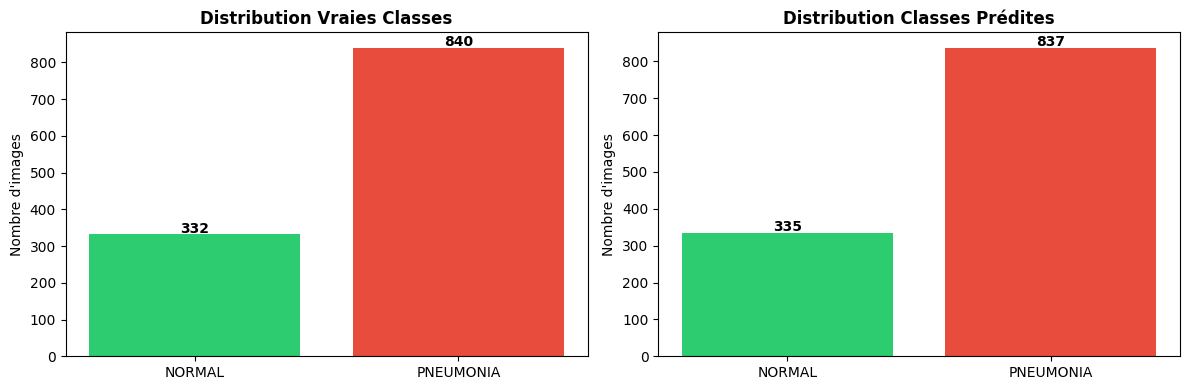

✅ Visualisation 1 créée

📊 Création visualisation 2/5: Matrice de confusion


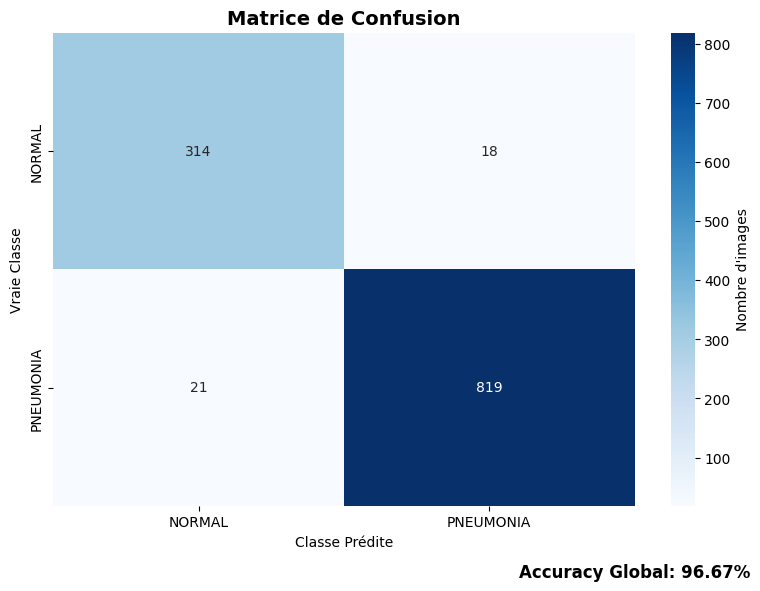

✅ Visualisation 2 créée

📊 Création visualisation 3/5: Distribution de confiance


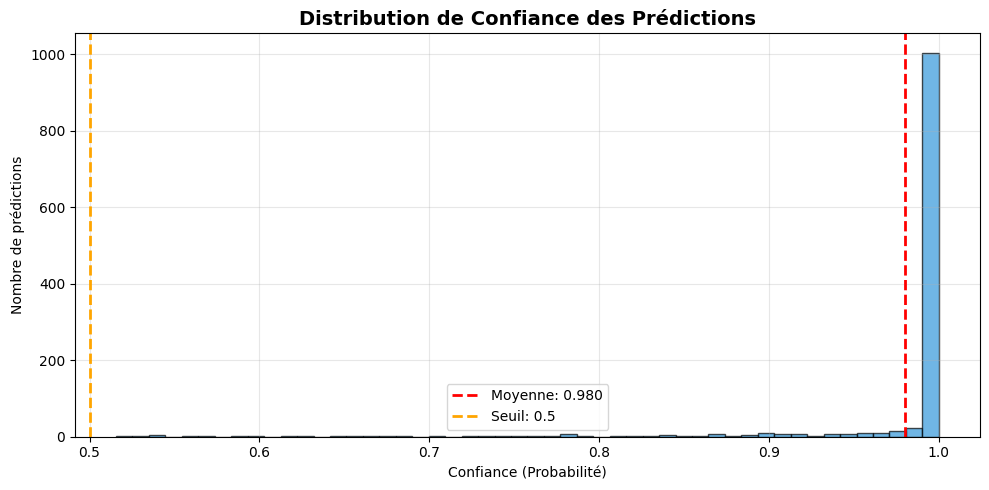

✅ Visualisation 3 créée

📊 Création visualisation 4/5: Métriques par classe


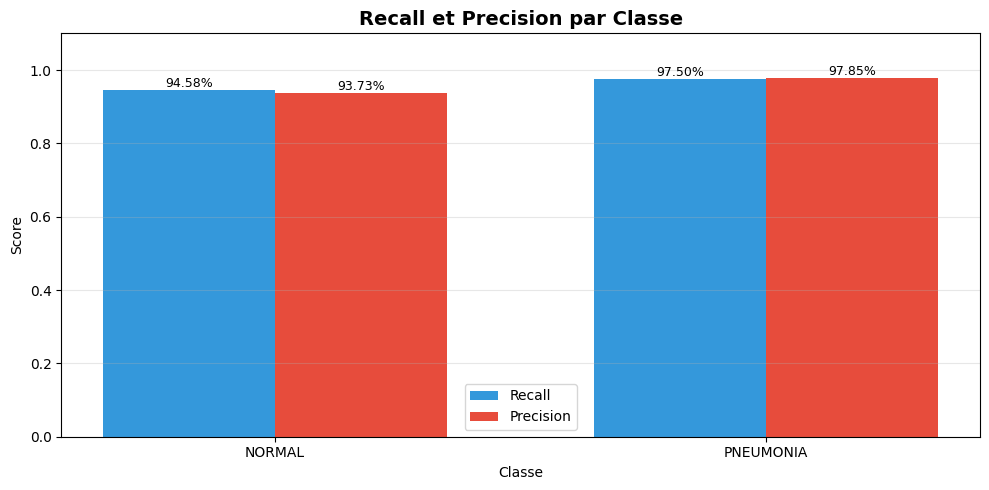

✅ Visualisation 4 créée

📊 Création visualisation 5/5: Courbe ROC


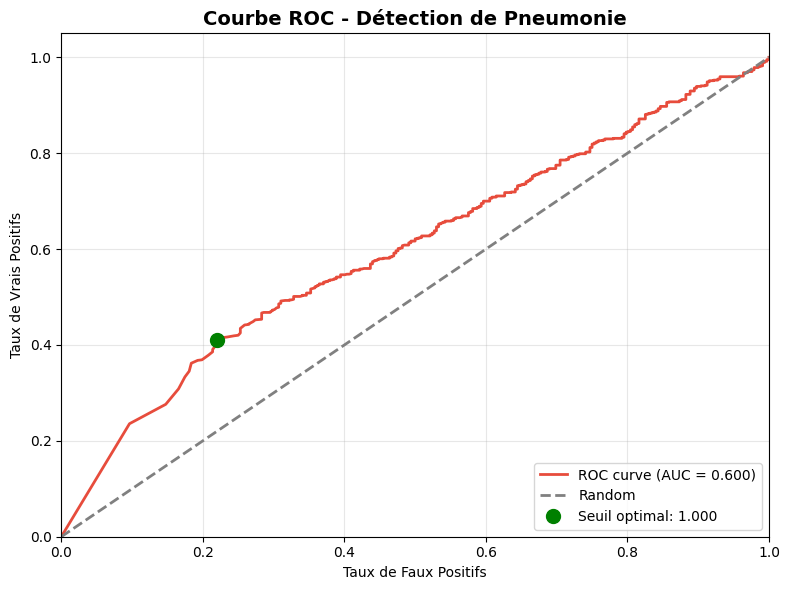

✅ Visualisation 5 créée

✅ TOUTES LES VISUALISATIONS GÉNÉRÉES AVEC SUCCÈS !


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("\n📊 GÉNÉRATION DES VISUALISATIONS")
print("=" * 60)

# Récupérer les données pour visualisations
viz_data = predictions_df.select("true_label", "predicted_label", "confidence").collect()
y_true = np.array([row['true_label'] for row in viz_data])
y_pred = np.array([row['predicted_label'] for row in viz_data])
y_scores = np.array([row['confidence'] for row in viz_data])

# ✅ CORRECTION: 2 classes uniquement
class_names = ['NORMAL', 'PNEUMONIA']

# ========== VIZ 1 : Distribution des classes ==========
print("\n📊 Création visualisation 1/5: Distribution des classes")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Vraies classes
unique_true, counts_true = np.unique(y_true, return_counts=True)
ax1.bar([class_names[i] for i in unique_true], counts_true, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Distribution Vraies Classes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nombre d\'images')
for i, v in enumerate(counts_true):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Classes prédites
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
ax2.bar([class_names[i] for i in unique_pred], counts_pred, color=['#2ecc71', '#e74c3c'])
ax2.set_title('Distribution Classes Prédites', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nombre d\'images')
for i, v in enumerate(counts_pred):
    ax2.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Visualisation 1 créée")

# ========== VIZ 2 : Matrice de confusion ==========
print("\n📊 Création visualisation 2/5: Matrice de confusion")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'images'}, ax=ax)
ax.set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
ax.set_ylabel('Vraie Classe')
ax.set_xlabel('Classe Prédite')

# Calculer l'accuracy global
accuracy = np.trace(cm) / np.sum(cm)
ax.text(1.0, -0.15, f'Accuracy Global: {accuracy:.2%}',
        ha='center', fontsize=12, fontweight='bold',
        transform=ax.transAxes)

plt.tight_layout()
plt.show()
print("✅ Visualisation 2 créée")

# ========== VIZ 3 : Distribution de confiance ==========
print("\n📊 Création visualisation 3/5: Distribution de confiance")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_scores, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax.axvline(y_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {y_scores.mean():.3f}')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Seuil: 0.5')
ax.set_xlabel('Confiance (Probabilité)')
ax.set_ylabel('Nombre de prédictions')
ax.set_title('Distribution de Confiance des Prédictions', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Visualisation 3 créée")

# ========== VIZ 4 : Métriques par classe ==========
print("\n📊 Création visualisation 4/5: Métriques par classe")

# Calculer précision et rappel
tn, fp, fn, tp = cm.ravel()

precision_normal = tn / (tn + fn) if (tn + fn) > 0 else 0
recall_normal = tn / (tn + fp) if (tn + fp) > 0 else 0

precision_pneumonia = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pneumonia = tp / (tp + fn) if (tp + fn) > 0 else 0

precisions = [precision_normal, precision_pneumonia]
recalls = [recall_normal, recall_pneumonia]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, recalls, width, label='Recall', color='#3498db')
bars2 = ax.bar(x + width/2, precisions, width, label='Precision', color='#e74c3c')

ax.set_xlabel('Classe')
ax.set_ylabel('Score')
ax.set_title('Recall et Precision par Classe', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Visualisation 4 créée")

# ========== VIZ 5 : Courbe ROC ==========
print("\n📊 Création visualisation 5/5: Courbe ROC")

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbe ROC - Détection de Pneumonie', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Trouver le meilleur seuil
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'go', markersize=10,
        label=f'Seuil optimal: {optimal_threshold:.3f}')
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
print("✅ Visualisation 5 créée")

print("\n" + "=" * 60)
print("✅ TOUTES LES VISUALISATIONS GÉNÉRÉES AVEC SUCCÈS !")
print("=" * 60)